In [7]:
import imageio
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import numpy as np
import os
import itertools
import pandas as pd

from module.preprocessing import *
from skimage import exposure, filters, morphology, measure, color, img_as_float

In [2]:
directory = "../dataset/Assigments/eye-tracking-dataset/IrisEye"

path = [f for f in os.listdir(directory) if f.endswith('.png')]

images = []

for file in path:
    img = imageio.imread(os.path.join(directory, file))
    images.append(img)
    
print(f"Total images: {len(images)}")

im = images[6]
im.shape

C:\Users\Putra\AppData\Local\Temp\ipykernel_32640\3356391222.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(os.path.join(directory, file))


Total images: 1759


(200, 200)

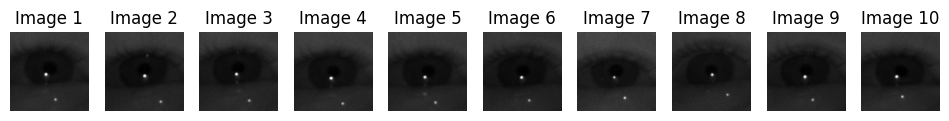

In [3]:
fig, ax = plt.subplots(1, 10, figsize=(12, 6))

# Display only 10 images for visualization
for i in range(10):
    ax[i].imshow(images[i+40], cmap='gray')
    ax[i].set_title(f"Image {i+1}")
    ax[i].axis("off")

plt.show()

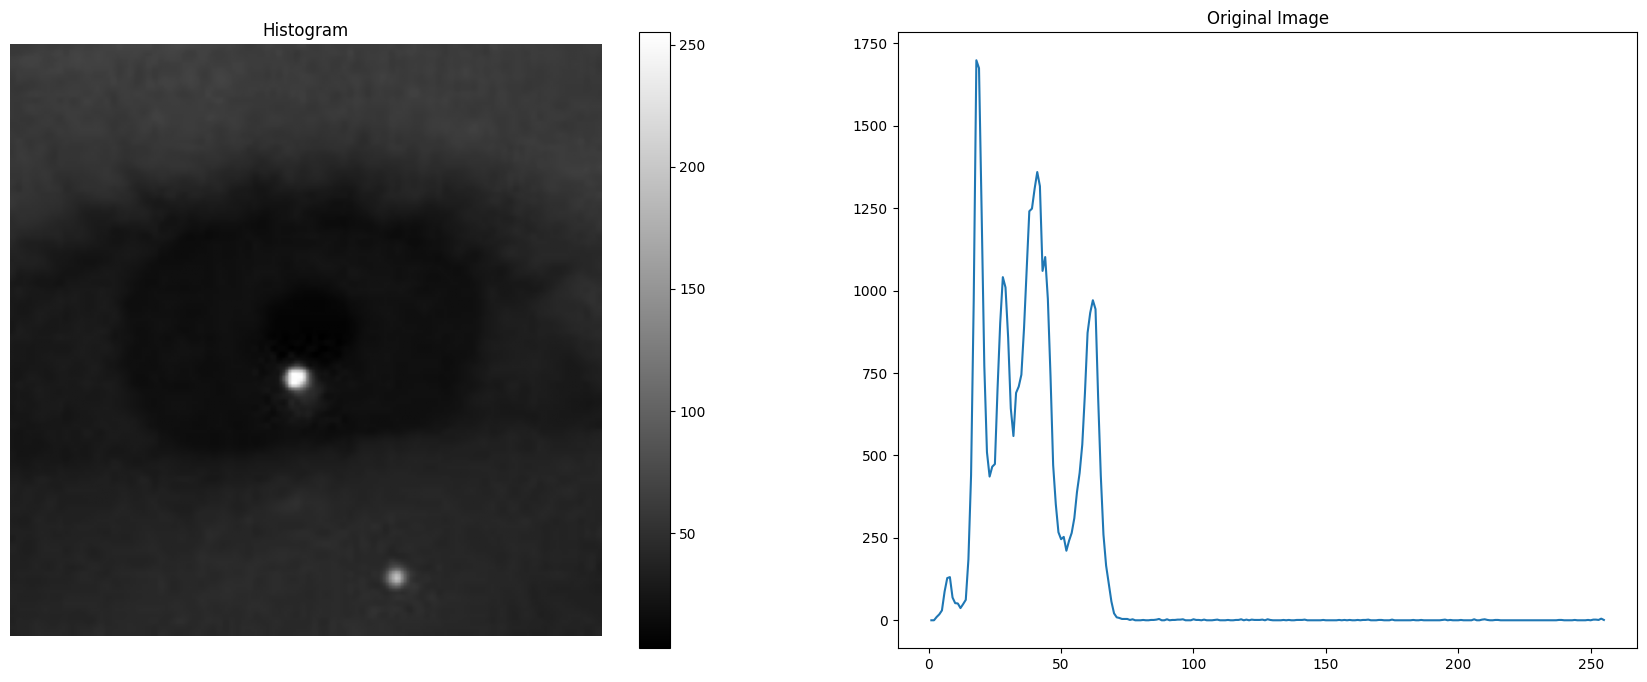

In [4]:
hist = ndi.histogram(im, min=0, max=255, bins=256)
x = np.arange(1, len(hist))

fig, ax = plt.subplots(1, 2, figsize=(21, 8))

im_display = ax[0].imshow(im, cmap='gray')
ax[0].set_title('Histogram')
ax[0].axis('off')

ax[1].plot(x, hist[1:])
ax[1].set_title('Original Image')

fig.colorbar(im_display, ax=ax[0])

plt.show()

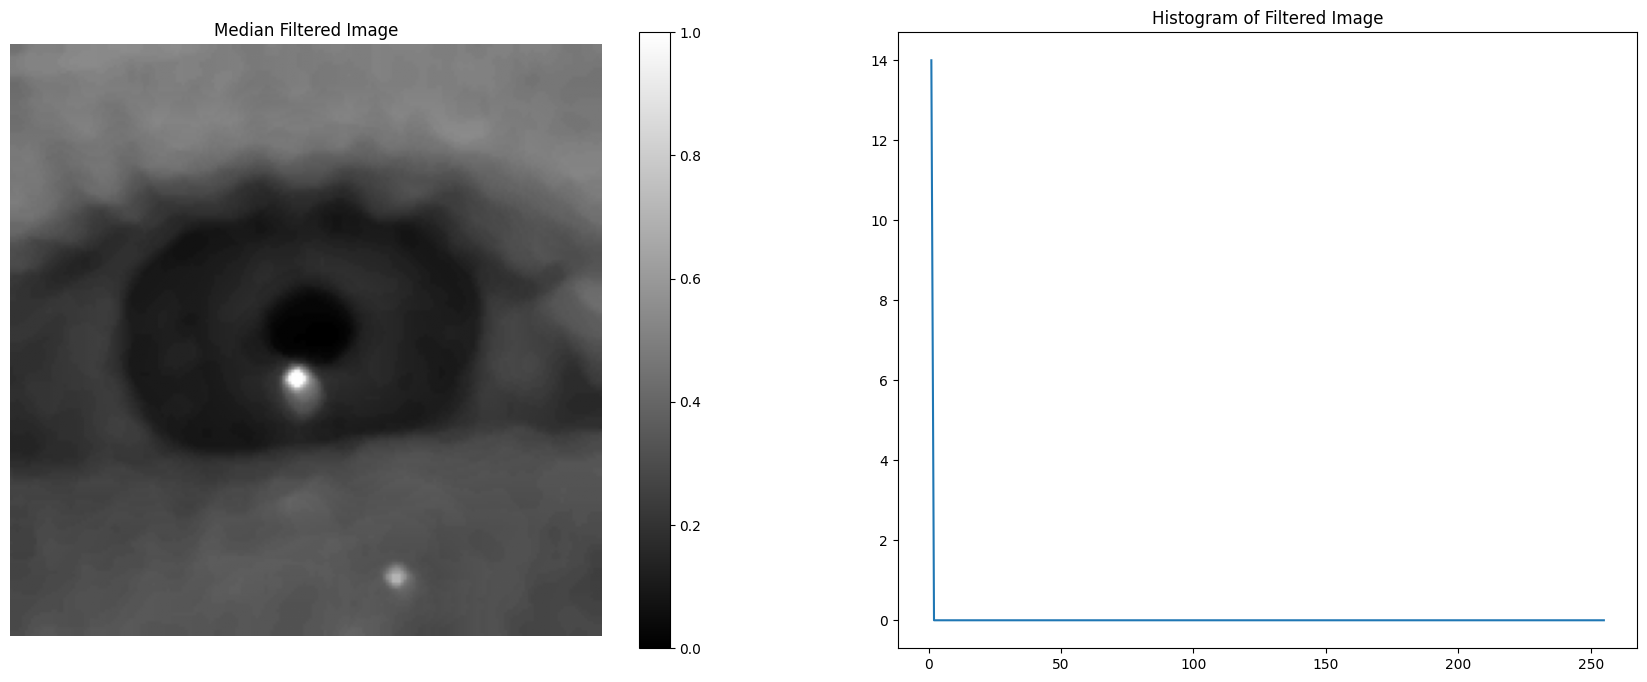

In [13]:
img_filt = ndi.median_filter(im, size=9)
img_filt = exposure.equalize_adapthist(img_filt, clip_limit=0.01)
filt_hist = ndi.histogram(img_filt, min=0, max=255, bins=256)

fig, ax = plt.subplots(1, 2, figsize=(21, 8))
im_display = ax[0].imshow(img_filt, cmap='gray')
ax[0].set_title('Median Filtered Image')
ax[0].axis('off')

ax[1].plot(x,filt_hist[1:])
ax[1].set_title('Histogram of Filtered Image')
fig.colorbar(im_display, ax=ax[0])
plt.show()

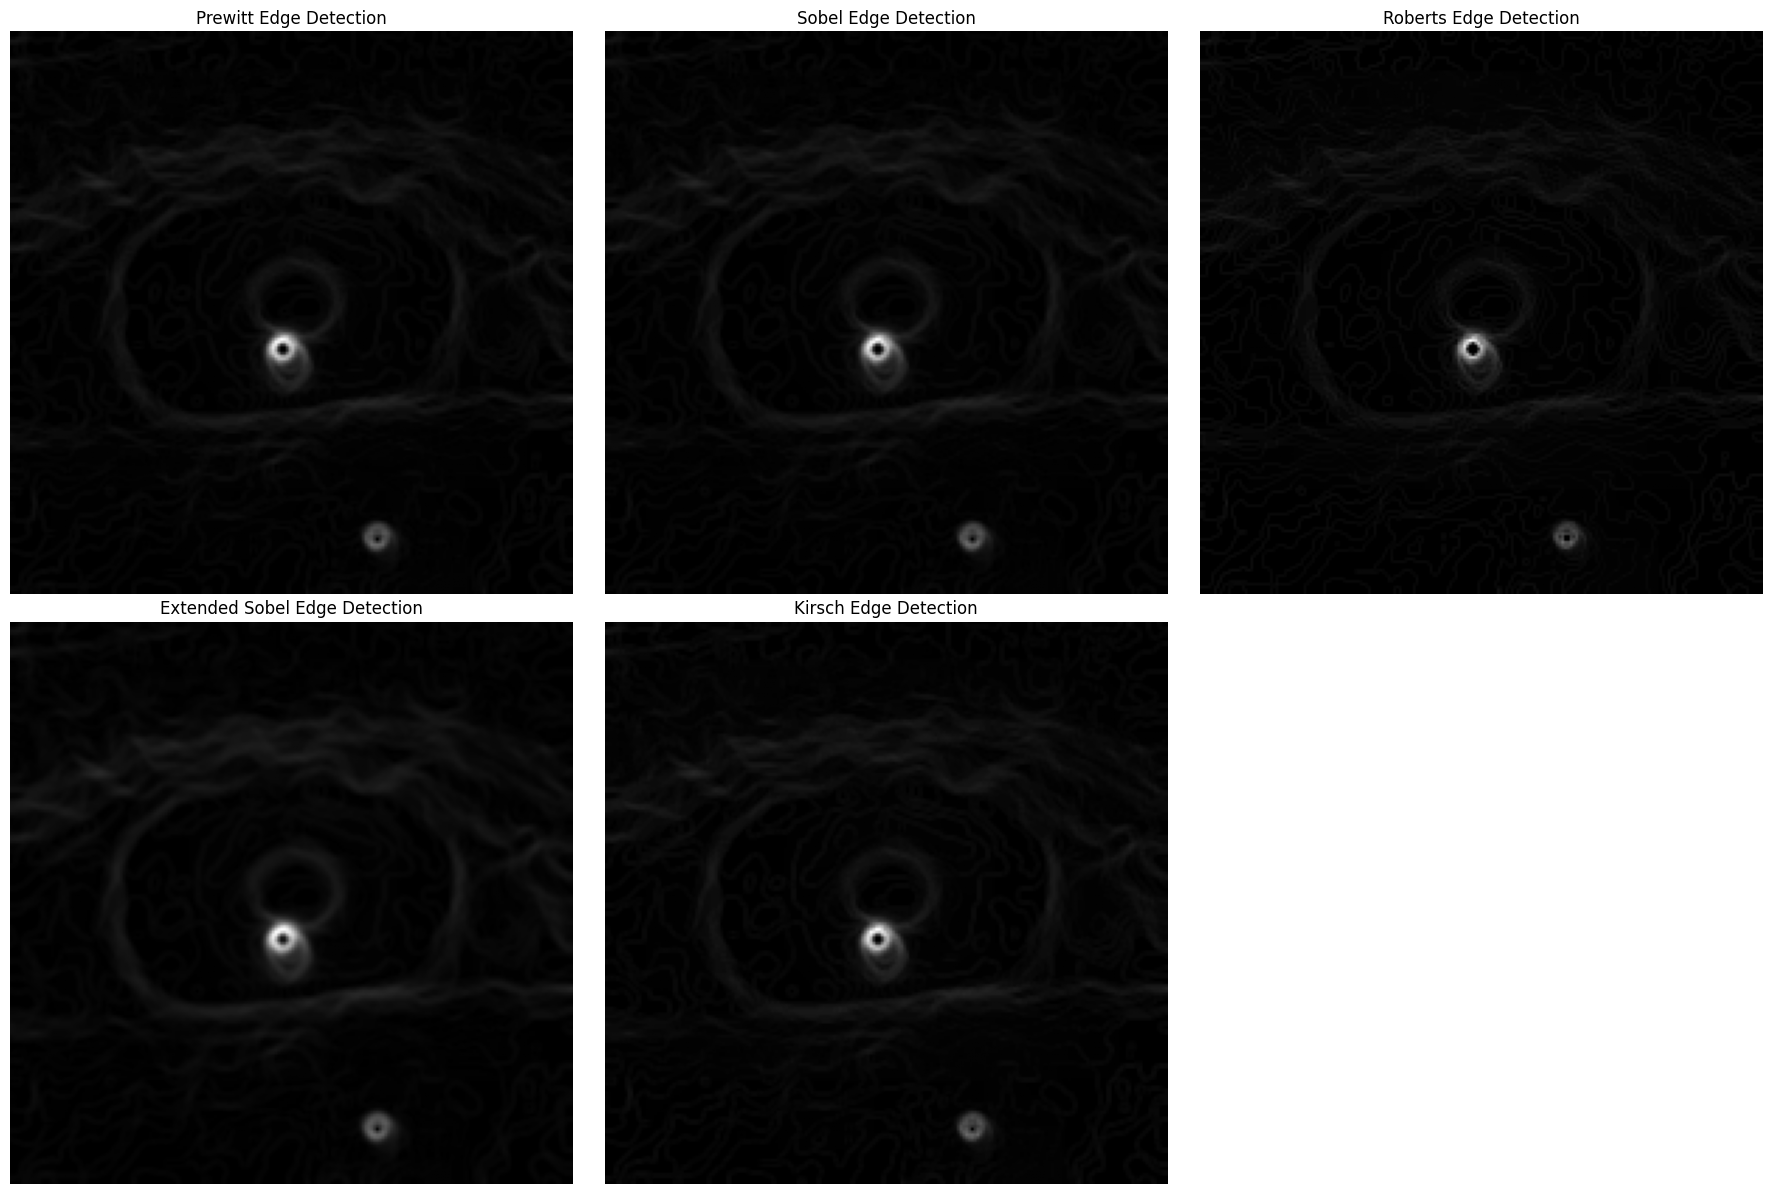

In [14]:
prewitt_image = prewitt(img_filt)
sobel_image = sobel(img_filt)
roberts_image = roberts(img_filt)
exsobel_image = extended_sobel(img_filt)
kirsch_image = kirsch(img_filt)

fig, ax = plt.subplots(2, 3, figsize=(18, 12))
ax[0, 0].imshow(prewitt_image, cmap='gray')
ax[0, 0].set_title('Prewitt Edge Detection')
ax[0, 0].axis('off')

ax[0, 1].imshow(sobel_image, cmap='gray')
ax[0, 1].set_title('Sobel Edge Detection')
ax[0, 1].axis('off')
ax[0, 2].imshow(roberts_image, cmap='gray')
ax[0, 2].set_title('Roberts Edge Detection')
ax[0, 2].axis('off')

ax[1, 0].imshow(exsobel_image, cmap='gray')
ax[1, 0].set_title('Extended Sobel Edge Detection')
ax[1, 0].axis('off')
ax[1, 1].imshow(kirsch_image, cmap='gray')
ax[1, 1].set_title('Kirsch Edge Detection')
ax[1, 1].axis('off')
ax[1, 2].axis('off')

plt.tight_layout()
plt.show()